<a href="https://colab.research.google.com/github/shloksatpathy/vision-inference-benchmark/blob/main/vision_inference_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi


Mon Sep 14 02:32:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             16W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
pip install ultralytics onnx onnx-runtime-gpu


ERROR: Could not find a version that satisfies the requirement onnx-runtime-gpu (from versions: none)
ERROR: No matching distribution found for onnx-runtime-gpu


Image downloaded successfully to downloaded_image.jpg


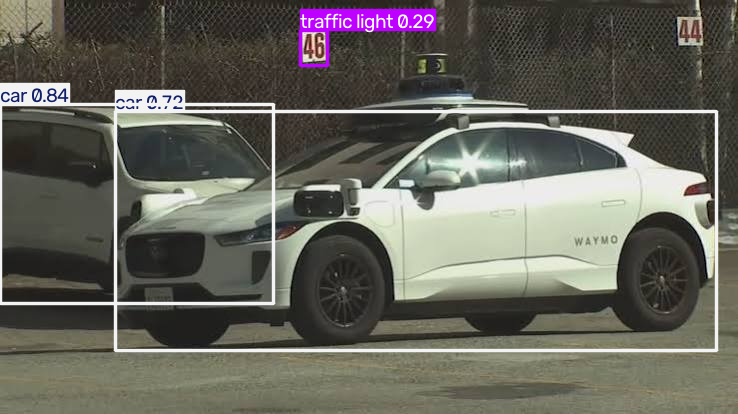

Cleaned up temporary image file: downloaded_image.jpg


In [3]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import os
import requests # Import requests to download the image

model = YOLO('yolov8n.pt')

image_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ2karG-sIF1xUTwlV0r6Qwy8AZgMu4tE1xbvSY2F7nBQ&s=10"

# Define a temporary filename for the downloaded image
image_filename = "downloaded_image.jpg"

# Download the image from the URL
try:
    response = requests.get(image_url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    with open(image_filename, "wb") as f:
        f.write(response.content)
    print(f"Image downloaded successfully to {image_filename}")
except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")
    # Handle the error appropriately if download fails
    exit()

# Load the image using OpenCV
img = cv2.imread(image_filename)

# Perform prediction on the OpenCV image (NumPy array)
# Set save=False and verbose=False to suppress unnecessary warnings for static images
results = model(img, save=False, imgsz=320, conf=0.25, verbose=False)

# Iterate through results to display the annotated image
for r in results:
  # YOLO's plot() method directly returns the annotated image as a NumPy array
  annotated_image = r.plot()

  # Display the image
  cv2_imshow(annotated_image)

# Clean up: remove the downloaded image file after use
if os.path.exists(image_filename):
    os.remove(image_filename)
    print(f"Cleaned up temporary image file: {image_filename}")